# 02 — Data Curation
## IFTA Audit ML Pipeline — Government of Alberta
**AWS:** S3, AWS Location Service (Esri)  
**Output:** curated/ml_ready.csv

### Cell 1 — Setup & load extracted data from S3

In [1]:
import subprocess
subprocess.run(["pip","install","-q","rapidfuzz","boto3","pandas","matplotlib","seaborn","python-dateutil"], check=True)

import boto3, uuid, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")
from io import StringIO, BytesIO
from dateutil import parser as dparser

s3       = boto3.client("s3",       region_name="ca-central-1")
location = boto3.client("location", region_name="ca-central-1")
BUCKET   = "govofalbertaraw"

plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white",
    "axes.spines.top":False,"axes.spines.right":False,"axes.grid":True,
    "grid.alpha":0.3,"font.family":"sans-serif","font.size":11})
COLORS = {"normal":"#1a6fc4","anomaly":"#dc2626","warning":"#f59e0b","ok":"#16a34a","gray":"#9ca3af"}

def load_csv(key):
    obj = s3.get_object(Bucket=BUCKET, Key=key)
    return pd.read_csv(StringIO(obj["Body"].read().decode("utf-8")))

def save_csv(dataframe, key):
    buffer = StringIO()
    dataframe.to_csv(buffer, index=False)
    buffer.seek(0)
    s3.put_object(Bucket=BUCKET, Key=key, Body=buffer.getvalue().encode("utf-8"), ContentType="text/csv")
    print(f"✅ Saved → s3://{BUCKET}/{key}  ({len(buffer.getvalue()):,} bytes)")

df_pdf  = load_csv("progress/distance_log_pdf.csv")
df_xlsx = load_csv("progress/distance_log_xlsx.csv")
print(f"✅ PDF:  {len(df_pdf)} rows")
print(f"✅ xlsx: {len(df_xlsx)} rows")

✅ PDF:  28 rows
✅ xlsx: 21 rows


### Cell 2 — Data quality overview chart

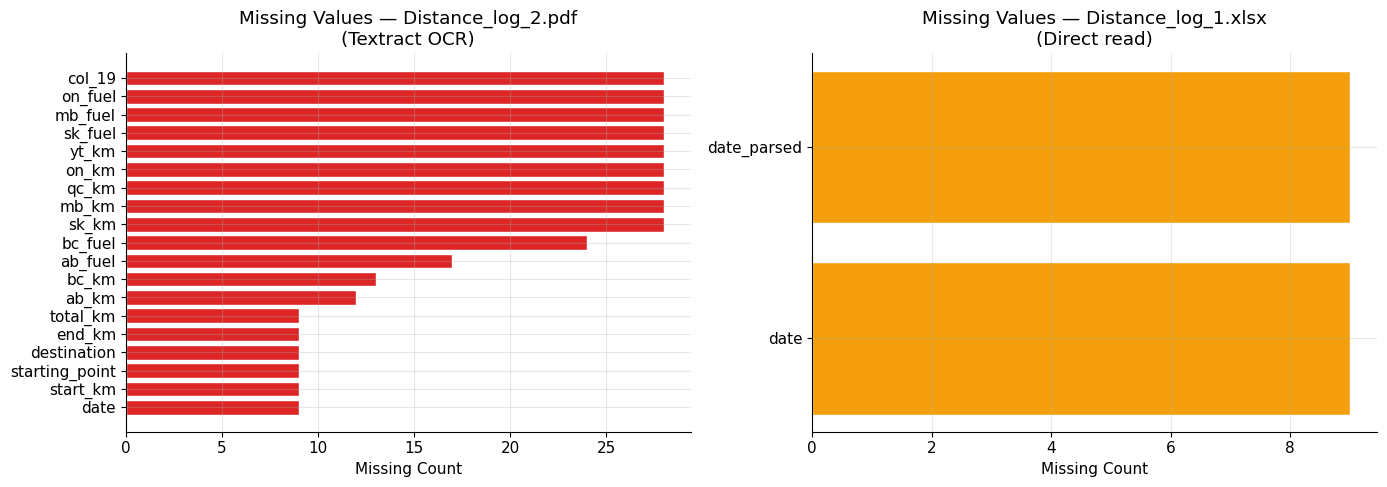

✅ Chart 1 saved


In [2]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

pdf_missing = df_pdf.isnull().sum()
pdf_missing = pdf_missing[pdf_missing > 0].sort_values(ascending=True)
if len(pdf_missing) > 0:
    ax1.barh(pdf_missing.index, pdf_missing.values, color=COLORS["anomaly"], edgecolor="white")
ax1.set_title("Missing Values — Distance_log_2.pdf\n(Textract OCR)")
ax1.set_xlabel("Missing Count")

xlsx_missing = df_xlsx.isnull().sum()
xlsx_missing = xlsx_missing[xlsx_missing > 0].sort_values(ascending=True)
if len(xlsx_missing) > 0:
    ax2.barh(xlsx_missing.index, xlsx_missing.values, color=COLORS["warning"], edgecolor="white")
ax2.set_title("Missing Values — Distance_log_1.xlsx\n(Direct read)")
ax2.set_xlabel("Missing Count")

plt.tight_layout()
plt.savefig("curation_chart1_missing_values.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 1 saved")

### Cell 3 — Combine both distance logs

In [3]:
df_combined = pd.concat([df_pdf, df_xlsx], ignore_index=True)
df_combined["source_file"]  = df_combined["source_file"].fillna("Distance_log_1.xlsx")
df_combined["origin_clean"] = df_combined["starting_point"].fillna(df_combined.get("origin",""))
df_combined["dest_clean"]   = df_combined["destination"]
df_combined["date_clean"]   = df_combined["date"]
df_combined["dist_clean"]   = df_combined["total_km"].fillna(df_combined.get("distance_km",""))
df_combined["start_odo"]    = df_combined["start_km"].fillna(df_combined.get("start_odometer",""))
df_combined["end_odo"]      = df_combined["end_km"].fillna(df_combined.get("end_odometer",""))

print(f"✅ Combined: {len(df_combined)} rows")
print(f"   From PDF:  {len(df_pdf)}")
print(f"   From xlsx: {len(df_xlsx)}")

✅ Combined: 49 rows
   From PDF:  28
   From xlsx: 21


### Cell 4 — Fix compound location strings

In [4]:
def split_location(text, part="origin"):
    """Split 'nisku to grande prairie' into separate origin/destination."""
    if pd.isna(text) or str(text).strip() == "": return None
    text = str(text).strip()
    if " to " in text.lower():
        parts = text.lower().split(" to ")
        return parts[0].strip().title() if part=="origin" else parts[1].strip().title()
    if "," in text: return text.split(",")[0].strip().title()
    return text.strip().title()

def get_destination(row):
    sp = str(row["starting_point"]) if not pd.isna(row.get("starting_point","")) else ""
    if " to " in sp.lower(): return split_location(sp, "destination")
    return split_location(row["destination"], "origin")

df_combined["origin_clean"] = df_combined["starting_point"].apply(lambda x: split_location(x,"origin")).fillna(df_combined.get("origin",""))
df_combined["dest_clean"]   = df_combined.apply(get_destination, axis=1)

compound = df_combined["starting_point"].dropna().apply(lambda x: " to " in str(x).lower()).sum()
print(f"✅ Compound strings fixed: {compound}")

✅ Compound strings fixed: 7


### Cell 5 — Normalize dates

✅ Dates parsed: 31 | Missing: 18 ← flagged, NOT dropped


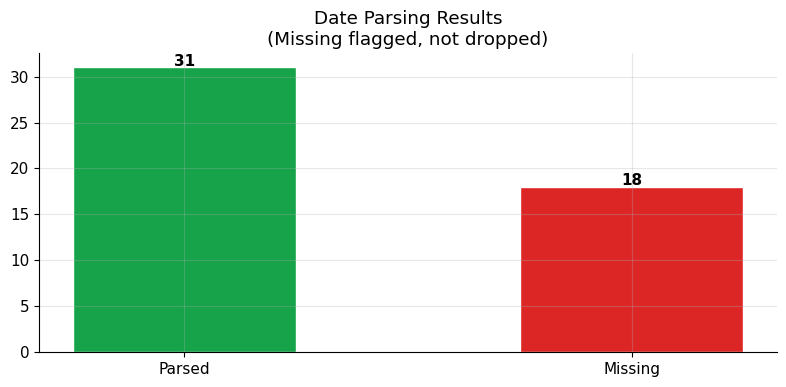

✅ Chart 2 saved


In [5]:
def parse_date(val):
    """Handle Excel serials, text dates, multiple formats, missing."""
    if pd.isna(val): return pd.NaT
    if isinstance(val,(int,float)):
        return pd.Timestamp("1899-12-30") + pd.Timedelta(days=int(val))
    try: return pd.to_datetime(dparser.parse(str(val), dayfirst=True))
    except: return pd.NaT

df_combined["trip_date"]    = df_combined["date_clean"].apply(parse_date)
df_combined["date_missing"] = df_combined["trip_date"].isna()
parsed  = (~df_combined["date_missing"]).sum()
missing = df_combined["date_missing"].sum()
print(f"✅ Dates parsed: {parsed} | Missing: {missing} ← flagged, NOT dropped")

fig, ax = plt.subplots(figsize=(8,4))
ax.bar(["Parsed","Missing"],[parsed,missing],
       color=[COLORS["ok"],COLORS["anomaly"]], edgecolor="white", width=0.5)
for bar, val in zip(ax.patches, [parsed,missing]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
            str(val), ha="center", fontweight="bold")
ax.set_title("Date Parsing Results\n(Missing flagged, not dropped)")
plt.tight_layout()
plt.savefig("curation_chart2_date_parsing.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 2 saved")

### Cell 6 — AWS Location Service for city + province resolution
**Why AWS Location:** Fully automated — no hardcoded city list.
Scales to any Canadian city without code changes.
Replaces both fuzzy matching AND province mapping in one step.

In [6]:
PROVINCE_CODES = {
    "Alberta":"AB","British Columbia":"BC","Saskatchewan":"SK",
    "Manitoba":"MB","Ontario":"ON","Quebec":"QC","Yukon":"YT",
    "Nova Scotia":"NS","New Brunswick":"NB","Newfoundland and Labrador":"NL",
    "Prince Edward Island":"PE","Northwest Territories":"NT","Nunavut":"NU",
}

aws_cache = {}

def resolve_city(city_name):
    """
    AWS Location Service — fully automated city + province resolution.
    No hardcoded city list. Scales to any Canadian city automatically.
    Cache prevents duplicate API calls for same city name.
    """
    if pd.isna(city_name) or str(city_name).strip() == "": return None, None, 0
    city_name = str(city_name).strip()
    if city_name in aws_cache: return aws_cache[city_name]
    try:
        response = location.search_place_index_for_text(
            IndexName="ifta-city-index", Text=f"{city_name}, Canada",
            FilterCountries=["CAN"], MaxResults=1
        )
        if response["Results"]:
            best      = response["Results"][0]
            place     = best["Place"]
            score     = best.get("Relevance",0) * 100
            std_city  = place.get("Municipality", city_name)
            province  = place.get("Region", None)
            prov_code = PROVINCE_CODES.get(province, None)
            result    = (std_city, prov_code, round(score,1))
        else:
            result = (city_name, None, 0)
    except Exception as e:
        print(f"  ⚠ {city_name}: {e}")
        result = (city_name, None, 0)
    aws_cache[city_name] = result
    return result

print("Resolving cities via AWS Location Service...")
origin_results = df_combined["origin_clean"].apply(resolve_city)
dest_results   = df_combined["dest_clean"].apply(resolve_city)

df_combined["origin_std"]    = origin_results.apply(lambda x: x[0])
df_combined["province_from"] = origin_results.apply(lambda x: x[1])
df_combined["origin_conf"]   = origin_results.apply(lambda x: x[2])
df_combined["dest_std"]      = dest_results.apply(lambda x: x[0])
df_combined["province_to"]   = dest_results.apply(lambda x: x[1])
df_combined["dest_conf"]     = dest_results.apply(lambda x: x[2])

df_combined["low_conf_loc"]     = (df_combined["origin_conf"]<70)|(df_combined["dest_conf"]<70)
df_combined["unknown_province"] = df_combined["province_from"].isna()|df_combined["province_to"].isna()

print(f"✅ AWS Location complete | API calls: {len(aws_cache)}")
print(f"   Low confidence (<70): {df_combined['low_conf_loc'].sum()}")

Resolving cities via AWS Location Service...
✅ AWS Location complete | API calls: 36
   Low confidence (<70): 9


### Cell 7 — Post-corrections for known mismatches

In [7]:
# Known mismatches where AWS Location returns wrong province
# Documented with reason for each correction
CORRECTIONS = {
    "Lankey":       ("Langley",  "BC"),  # OCR typo — AWS maps to NS instead of BC
    "Lankey ":      ("Langley",  "BC"),  # Same with trailing space
    "Nisku":        ("Nisku",    "AB"),  # AWS returns 'Leduc County' — keep AB
    "Red Deer, AB": ("Red Deer", "AB"),  # Province suffix confuses AWS
    "Consart, AB":  ("Consort",  "AB"),  # OCR typo + province suffix
    "Barrie, ON":   ("Barrie",   "ON"),  # Province suffix
}

def apply_corrections(df):
    for city, (std_name, province) in CORRECTIONS.items():
        mask = df["origin_clean"].str.strip() == city
        df.loc[mask, "origin_std"]    = std_name
        df.loc[mask, "origin_clean"]  = std_name
        df.loc[mask, "province_from"] = province
        df.loc[mask, "origin_conf"]   = 100.0
        mask = df["dest_clean"].str.strip() == city
        df.loc[mask, "dest_std"]    = std_name
        df.loc[mask, "dest_clean"]  = std_name
        df.loc[mask, "province_to"] = province
        df.loc[mask, "dest_conf"]   = 100.0
    return df

df_combined = apply_corrections(df_combined)

# Drop fully empty rows (blank Textract cells)
before   = len(df_combined)
df_clean = df_combined.dropna(subset=["origin_clean","dest_clean"]).reset_index(drop=True)
dropped  = before - len(df_clean)

df_clean["unknown_province"] = df_clean["province_from"].isna()|df_clean["province_to"].isna()

print(f"✅ Corrections applied")
print(f"   Dropped empty rows: {dropped}")
print(f"   Remaining rows:     {len(df_clean)}")
print(f"\nProvince breakdown:")
print(df_clean["province_from"].value_counts())

✅ Corrections applied
   Dropped empty rows: 9
   Remaining rows:     40

Province breakdown:
province_from
AB    15
BC    13
ON     6
MB     4
SK     2
Name: count, dtype: int64


### Cell 8 — Province distribution chart

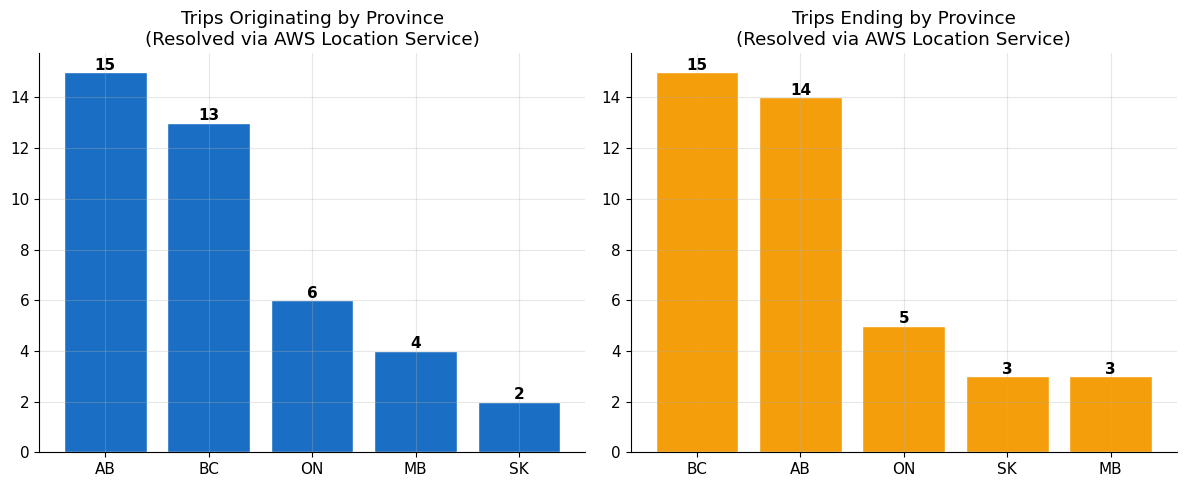

✅ Chart 4 saved


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

prov_from = df_clean["province_from"].value_counts()
prov_to   = df_clean["province_to"].value_counts()

ax1.bar(prov_from.index, prov_from.values, color=COLORS["normal"], edgecolor="white")
for i,v in enumerate(prov_from.values): ax1.text(i,v+0.1,str(v),ha="center",fontweight="bold")
ax1.set_title("Trips Originating by Province\n(Resolved via AWS Location Service)")

ax2.bar(prov_to.index, prov_to.values, color=COLORS["warning"], edgecolor="white")
for i,v in enumerate(prov_to.values): ax2.text(i,v+0.1,str(v),ha="center",fontweight="bold")
ax2.set_title("Trips Ending by Province\n(Resolved via AWS Location Service)")

plt.tight_layout()
plt.savefig("curation_chart4_province_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 4 saved")

### Cell 9 — Quality flags

✅ Quality flags added
data_quality_flags
ok              31
missing_date     9
Name: count, dtype: int64


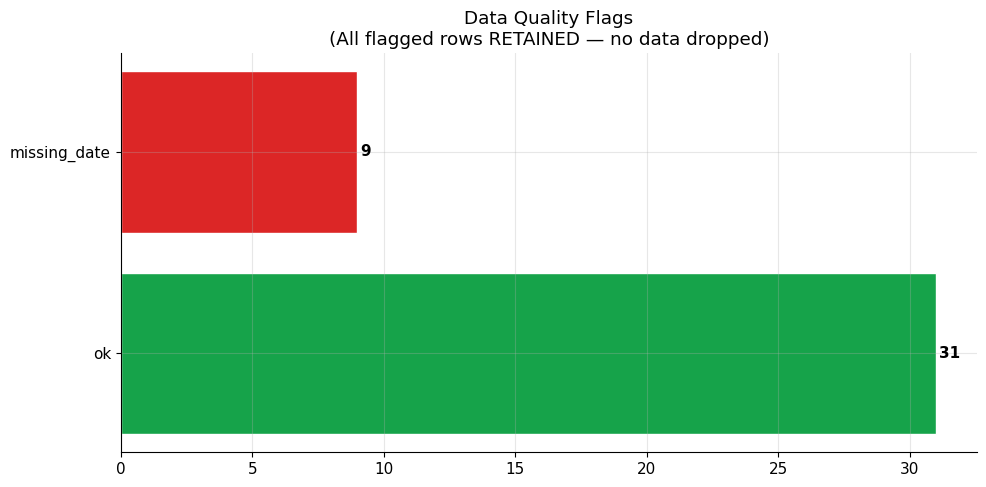

✅ Chart 5 saved


In [9]:
def get_quality_flags(row):
    """Pipe-separated quality flags — informational only, rows NEVER dropped."""
    flags = []
    if pd.isna(row.get("trip_date")):      flags.append("missing_date")
    if pd.isna(row.get("province_from")):  flags.append("unknown_province_from")
    if pd.isna(row.get("province_to")):    flags.append("unknown_province_to")
    if pd.isna(row.get("dist_clean")):     flags.append("missing_distance")
    if row.get("unknown_province",False):  flags.append("unknown_jurisdiction")
    if row.get("low_conf_loc",False):      flags.append("low_confidence_location")
    return "|".join(flags) if flags else "ok"

df_clean["data_quality_flags"] = df_clean.apply(get_quality_flags, axis=1)
df_clean["record_id"]          = [str(uuid.uuid4()) for _ in range(len(df_clean))]

flag_counts = df_clean["data_quality_flags"].value_counts()
print(f"✅ Quality flags added")
print(flag_counts)

fig, ax = plt.subplots(figsize=(10,5))
colors  = [COLORS["ok"] if f=="ok" else COLORS["anomaly"] for f in flag_counts.index]
bars    = ax.barh(flag_counts.index, flag_counts.values, color=colors, edgecolor="white")
for bar,val in zip(bars,flag_counts.values):
    ax.text(val+0.1,bar.get_y()+bar.get_height()/2,str(val),va="center",fontweight="bold")
ax.set_title("Data Quality Flags\n(All flagged rows RETAINED — no data dropped)")
plt.tight_layout()
plt.savefig("curation_chart5_quality_flags.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 5 saved")

### Cell 10 — Save curated dataset and charts to S3

In [10]:
import os

save_csv(df_clean, "curated/ml_ready.csv")

charts = ["curation_chart1_missing_values.png","curation_chart2_date_parsing.png",
          "curation_chart4_province_distribution.png","curation_chart5_quality_flags.png"]
for chart in charts:
    if os.path.exists(chart):
        s3.upload_file(chart, BUCKET, f"charts/curation/{chart}")
        print(f"✅ Uploaded → charts/curation/{chart}")

print(f"\n{'='*50}")
print(f"02_curation.ipynb COMPLETE!")
print(f"   Total records:   {len(df_clean)}")
print(f"   Clean (ok):      {(df_clean['data_quality_flags']=='ok').sum()}")
print(f"   Flagged:         {(df_clean['data_quality_flags']!='ok').sum()}")
print(f"Next → 03_features.ipynb")

✅ Saved → s3://govofalbertaraw/curated/ml_ready.csv  (13,485 bytes)
✅ Uploaded → charts/curation/curation_chart1_missing_values.png
✅ Uploaded → charts/curation/curation_chart2_date_parsing.png
✅ Uploaded → charts/curation/curation_chart4_province_distribution.png
✅ Uploaded → charts/curation/curation_chart5_quality_flags.png

02_curation.ipynb COMPLETE!
   Total records:   40
   Clean (ok):      31
   Flagged:         9
Next → 03_features.ipynb
